<a href="https://colab.research.google.com/github/bhoomikgupta/MachineLearning/blob/main/student_performance_EWS_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

print("All libraries imported successfully!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")


All libraries imported successfully!
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


---
## 🔧 Task 2: Data Preprocessing

In [37]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# If running on Google Colab, upload the CSV first:
# from google.colab import files
# files.upload()

df = pd.read_csv('student_performance_dataset.csv')  # update path if needed

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Memory Usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print("Column Info:")
print(df.dtypes.to_string())
print()
print("First 5 rows:")
df.head()


  DATASET OVERVIEW
  Shape          : 1000 rows × 8 columns
  Memory Usage   : 106.9 KB

Column Info:
Study_Hours          int64
Attendance           int64
Previous_Marks       int64
Assignment_Score     int64
Sleep_Hours          int64
Internet_Usage      object
Extra_Coaching       int64
Pass                 int64

First 5 rows:


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Internet_Usage,Extra_Coaching,Pass
0,7,63,35,38,4,Low,0,0
1,4,62,90,66,4,High,1,0
2,8,98,49,78,8,Medium,1,0
3,5,47,31,70,8,High,0,1
4,7,93,66,46,4,Medium,1,1


In [38]:
# ── Missing Value Check ───────────────────────────────────────────────────────
print("Missing Values per Column:")
missing = df.isnull().sum()
for col, n in missing.items():
    status = "Clean" if n == 0 else f"  {n} missing"
    print(f"  {col:20s}: {status}")
print(f"\nTotal missing values: {missing.sum()} — Dataset is complete.")


Missing Values per Column:
  Study_Hours         : Clean
  Attendance          : Clean
  Previous_Marks      : Clean
  Assignment_Score    : Clean
  Sleep_Hours         : Clean
  Internet_Usage      : Clean
  Extra_Coaching      : Clean
  Pass                : Clean

Total missing values: 0 — Dataset is complete.


In [39]:
# ── Statistical Summary ───────────────────────────────────────────────────────
print("Descriptive Statistics:")
df.describe().round(2)


Descriptive Statistics:


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Extra_Coaching,Pass
count,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,4.9,70.08,63.67,65.53,6.58,0.51,0.46
std,2.6,17.20,20.25,19.99,1.72,0.50,0.50
min,1.0,40.00,30.00,30.00,4.00,0.00,0.00
25%,3.0,55.00,46.00,48.00,5.00,0.00,0.00
50%,5.0,71.00,63.00,66.00,7.00,1.00,0.00
75%,7.0,84.25,81.00,83.00,8.00,1.00,1.00
max,9.0,99.00,99.00,99.00,9.00,1.00,1.00


In [40]:
# ── Encode Categorical Variable ───────────────────────────────────────────────
le = LabelEncoder()
df['Internet_Usage_enc'] = le.fit_transform(df['Internet_Usage'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Internet_Usage Label Encoding:")
for k, v in mapping.items():
    print(f"  '{k}' → {v}")

# ── Define Features and Target ────────────────────────────────────────────────
feature_cols = ['Study_Hours', 'Attendance', 'Previous_Marks',
                'Assignment_Score', 'Sleep_Hours', 'Internet_Usage_enc', 'Extra_Coaching']
X = df[feature_cols]
y = df['Pass']

print(f"\nFeatures (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nClass distribution :")
print(f"  Fail (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Pass (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")


Internet_Usage Label Encoding:
  'High' → 0
  'Low' → 1
  'Medium' → 2

Features (X) shape : (1000, 7)
Target   (y) shape : (1000,)

Class distribution :
  Fail (0): 543 (54.3%)
  Pass (1): 457 (45.7%)


In [41]:
# ── Train-Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train-Test Split (80/20, Stratified):")
print(f"  Training set : {X_train.shape[0]} samples  "
      f"(Fail={( y_train==0).sum()}, Pass={(y_train==1).sum()})")
print(f"  Test set     : {X_test.shape[0]} samples   "
      f"(Fail={(y_test==0).sum()},  Pass={(y_test==1).sum()})")

# ── Feature Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)       # fit on train only — prevent data leakage

print("\nStandardScaler applied (fit on train, transform on test).")
print(f"  Scaled mean (should ≈ 0): {X_train_sc.mean(axis=0).round(3)}")
print(f"  Scaled std  (should ≈ 1): {X_train_sc.std(axis=0).round(3)}")


Train-Test Split (80/20, Stratified):
  Training set : 800 samples  (Fail=434, Pass=366)
  Test set     : 200 samples   (Fail=109,  Pass=91)

StandardScaler applied (fit on train, transform on test).
  Scaled mean (should ≈ 0): [-0.  0.  0. -0.  0.  0.  0.]
  Scaled std  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1.]


---
## 📊 Task 3: Exploratory Data Analysis

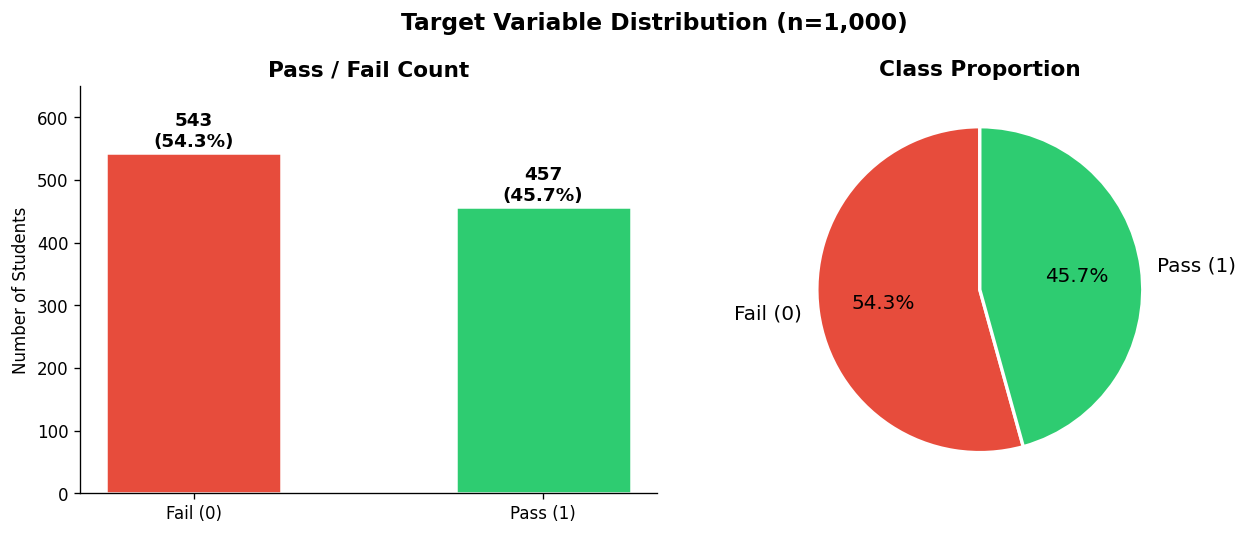


Observation: Dataset is mildly imbalanced (54.3% Fail vs 45.7% Pass).
This motivates using F1-Score and ROC-AUC as primary metrics (not just accuracy).


In [42]:
# ── Fig 1: Target Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
counts = y.value_counts().sort_index()

bars = axes[0].bar(['Fail (0)', 'Pass (1)'], counts.values,
                   color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Pass / Fail Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
axes[0].set_ylim(0, 650)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=['Fail (0)', 'Pass (1)'],
            colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution (n=1,000)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nObservation: Dataset is mildly imbalanced (54.3% Fail vs 45.7% Pass).")
print("This motivates using F1-Score and ROC-AUC as primary metrics (not just accuracy).")


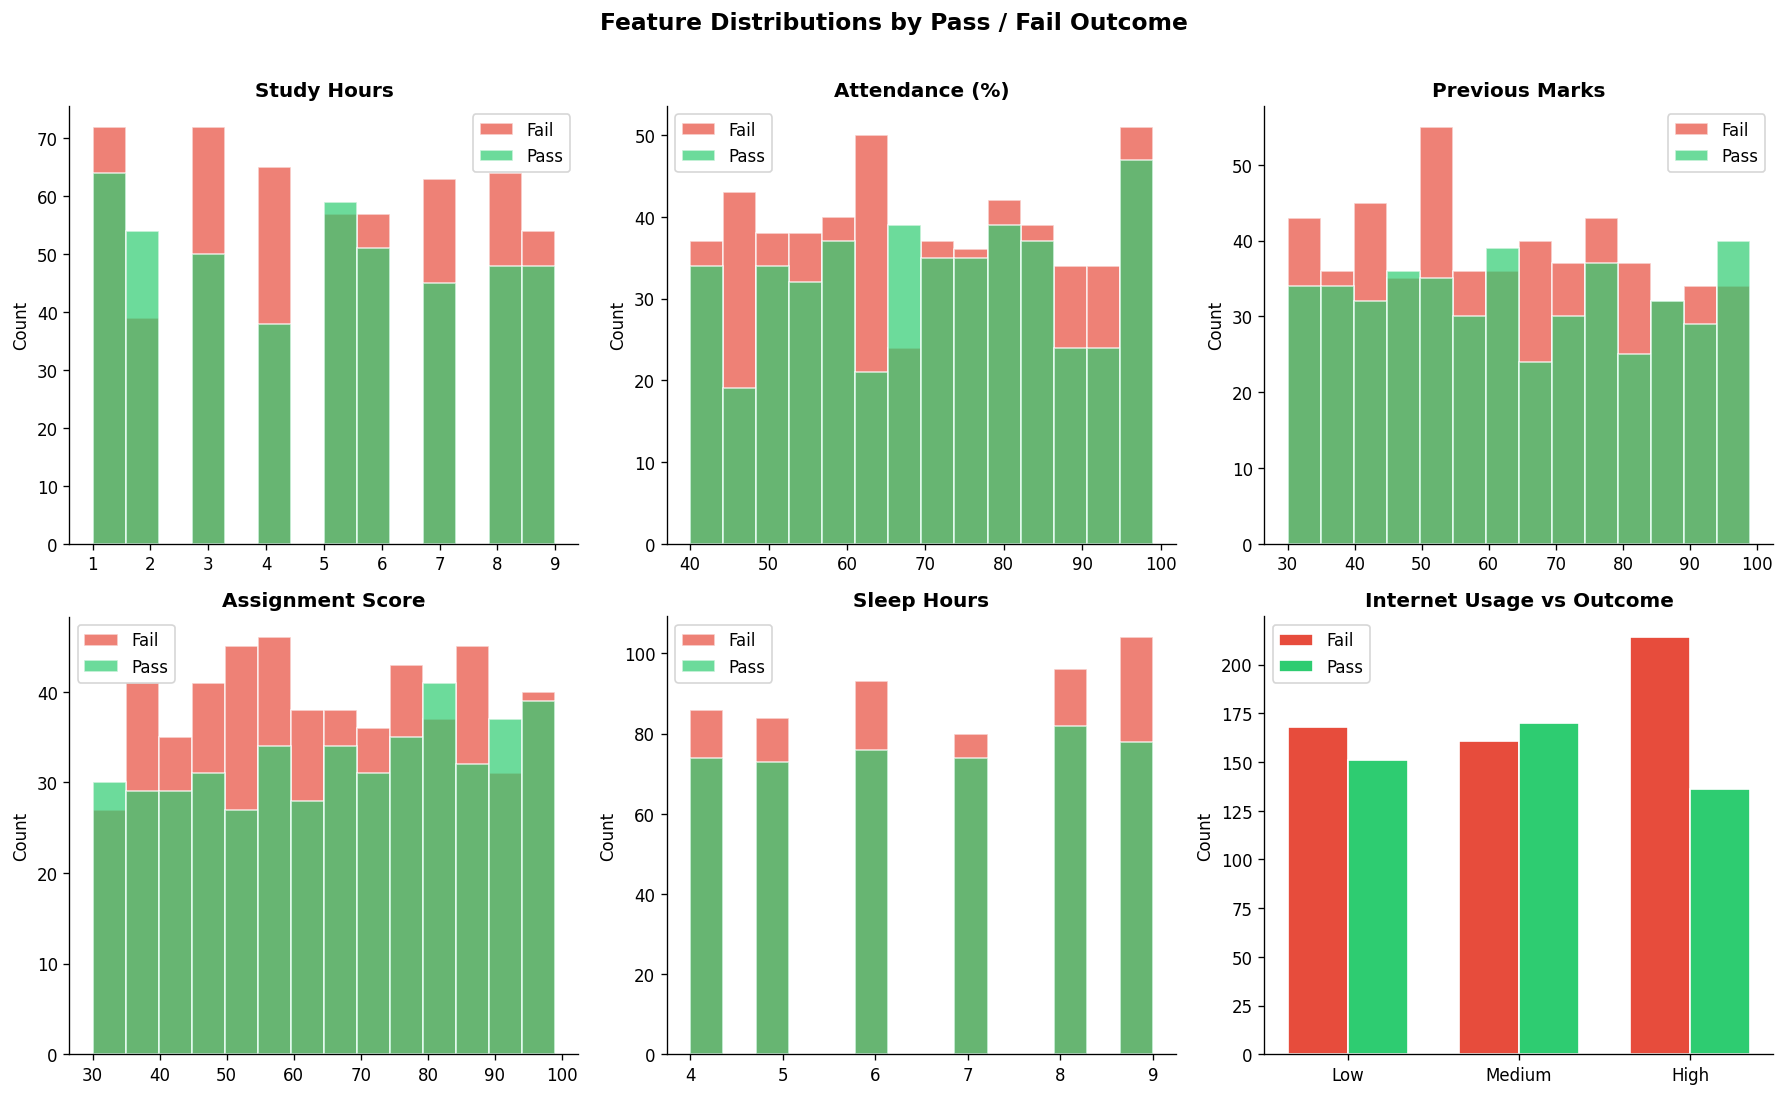

In [43]:
# ── Fig 2: Feature Distributions by Outcome ───────────────────────────────────
num_cols = ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Sleep_Hours']
col_labels = ['Study Hours', 'Attendance (%)', 'Previous Marks', 'Assignment Score', 'Sleep Hours']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(num_cols, col_labels)):
    for lbl, color, name in [(0,'#E74C3C','Fail'),(1,'#2ECC71','Pass')]:
        axes[i].hist(df[df['Pass']==lbl][col], bins=14, alpha=0.70,
                     color=color, label=name, edgecolor='white')
    axes[i].set_title(label, fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Count'); axes[i].legend()

# Internet Usage grouped bar
iu = df.groupby(['Internet_Usage', 'Pass']).size().unstack().reindex(['Low','Medium','High'])
x_pos = np.arange(3); w = 0.35
axes[5].bar(x_pos-w/2, iu[0], w, color='#E74C3C', edgecolor='white', label='Fail')
axes[5].bar(x_pos+w/2, iu[1], w, color='#2ECC71', edgecolor='white', label='Pass')
axes[5].set_xticks(x_pos); axes[5].set_xticklabels(['Low','Medium','High'])
axes[5].set_title('Internet Usage vs Outcome', fontweight='bold', fontsize=12)
axes[5].set_ylabel('Count'); axes[5].legend()

plt.suptitle('Feature Distributions by Pass / Fail Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


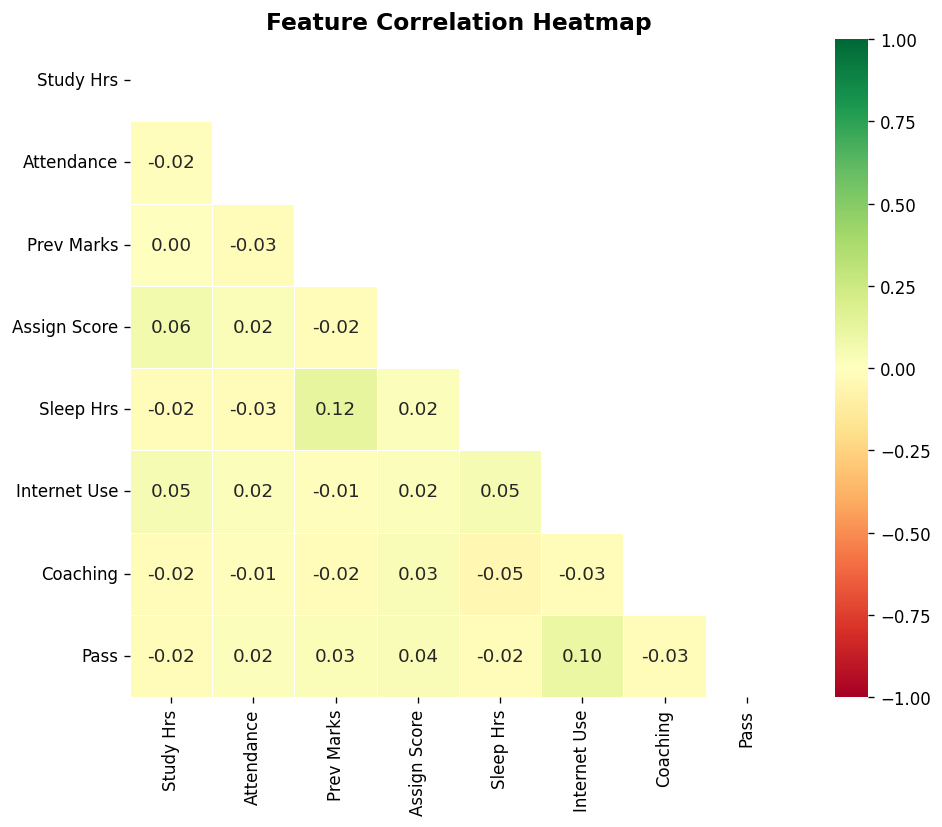


Correlation with Pass (target):
  ▲ Internet Use   : +0.104  ██
  ▲ Assign Score   : +0.035  
  ▲ Prev Marks     : +0.028  
  ▲ Attendance     : +0.022  
  ▼ Sleep Hrs      : -0.016  
  ▼ Study Hrs      : -0.025  
  ▼ Coaching       : -0.028  


In [44]:
# ── Fig 3: Correlation Heatmap ────────────────────────────────────────────────
corr_df = df[['Study_Hours','Attendance','Previous_Marks','Assignment_Score',
              'Sleep_Hours','Internet_Usage_enc','Extra_Coaching','Pass']].copy()
corr_df.columns = ['Study Hrs','Attendance','Prev Marks','Assign Score',
                   'Sleep Hrs','Internet Use','Coaching','Pass']

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size':11}, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nCorrelation with Pass (target):")
corr_with_target = corr_df.corr()['Pass'].drop('Pass').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    bar = '█' * int(abs(val) * 20)
    direction = '▲' if val > 0 else '▼'
    print(f"  {direction} {feat:15s}: {val:+.3f}  {bar}")


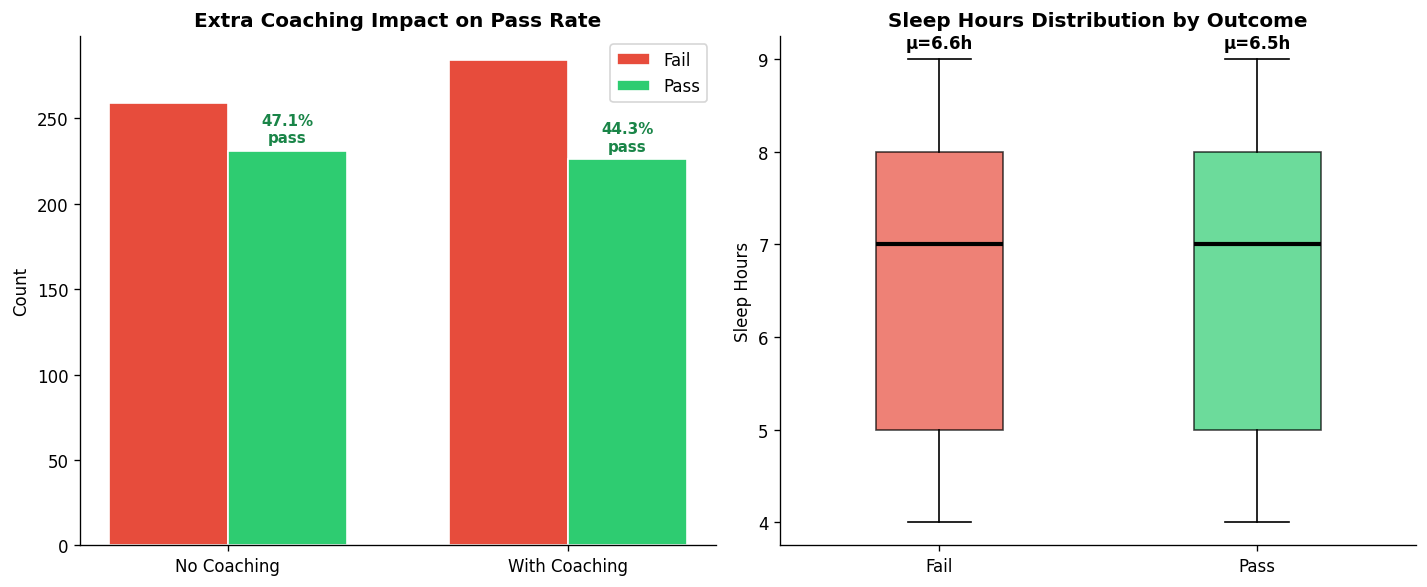

Pass rate WITHOUT coaching : 47.1%
Pass rate WITH coaching    : 44.3%

Avg sleep — Fail: 6.60h  |  Pass: 6.55h


In [45]:
# ── Fig 4: Extra Coaching & Sleep Hours ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Coaching impact
ec = df.groupby(['Extra_Coaching','Pass']).size().unstack()
x_pos = np.arange(2); w = 0.35
axes[0].bar(x_pos-w/2, ec[0], w, color='#E74C3C', edgecolor='white', label='Fail')
axes[0].bar(x_pos+w/2, ec[1], w, color='#2ECC71', edgecolor='white', label='Pass')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(['No Coaching','With Coaching'])
for grp in [0,1]:
    pr = ec.loc[grp,1] / ec.loc[grp].sum() * 100
    axes[0].text(grp+w/2, ec.loc[grp,1]+5, f'{pr:.1f}%\npass',
                 ha='center', fontsize=9, color='#1A8548', fontweight='bold')
axes[0].set_title('Extra Coaching Impact on Pass Rate', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count'); axes[0].legend()

# Sleep hours boxplot
data_fail = df[df['Pass']==0]['Sleep_Hours']
data_pass = df[df['Pass']==1]['Sleep_Hours']
bp = axes[1].boxplot([data_fail, data_pass], positions=[0,1], patch_artist=True, widths=0.4,
                     medianprops=dict(color='black', linewidth=2.5))
bp['boxes'][0].set_facecolor('#E74C3C'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ECC71'); bp['boxes'][1].set_alpha(0.7)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Fail','Pass'])
axes[1].set_title('Sleep Hours Distribution by Outcome', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sleep Hours')
for i, d in enumerate([data_fail, data_pass]):
    axes[1].text(i, d.max()+0.12, f'μ={d.mean():.1f}h', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

print(f"Pass rate WITHOUT coaching : {df[df['Extra_Coaching']==0]['Pass'].mean()*100:.1f}%")
print(f"Pass rate WITH coaching    : {df[df['Extra_Coaching']==1]['Pass'].mean()*100:.1f}%")
print(f"\nAvg sleep — Fail: {data_fail.mean():.2f}h  |  Pass: {data_pass.mean():.2f}h")


In [46]:
# ── Define & Train All Models ─────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, kernel='rbf', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>8} {'ROC-AUC':>10}")
print("-" * 75)

for name, mdl in models.items():
    use_scaled = name in ('Logistic Regression', 'SVM')
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values

    mdl.fit(Xtr, y_train)
    preds = mdl.predict(Xte)
    proba = mdl.predict_proba(Xte)[:, 1]
    rpt   = classification_report(y_test, preds, output_dict=True)

    results[name] = dict(
        model=mdl, preds=preds, proba=proba,
        accuracy  = accuracy_score(y_test, preds),
        precision = rpt['1']['precision'],
        recall    = rpt['1']['recall'],
        f1        = rpt['1']['f1-score'],
        roc_auc   = roc_auc_score(y_test, proba),
        report    = classification_report(y_test, preds),
        cm        = confusion_matrix(y_test, preds)
    )
    r = results[name]
    star = " ★" if name == 'Random Forest' else ""
    print(f"{name+star:<25} {r['accuracy']:>10.3f} {r['precision']:>11.3f} "
          f"{r['recall']:>9.3f} {r['f1']:>8.3f} {r['roc_auc']:>10.3f}")

print("\n★ = Recommended model")


Model                       Accuracy   Precision    Recall       F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression            0.500       0.415     0.242    0.306      0.549
Decision Tree                  0.520       0.474     0.495    0.484      0.542
Random Forest ★                0.580       0.554     0.396    0.462      0.601
SVM                            0.565       0.538     0.308    0.392      0.588
Gradient Boosting              0.565       0.526     0.440    0.479      0.577

★ = Recommended model


In [47]:
# ── Detailed Classification Reports ──────────────────────────────────────────
for name, res in results.items():
    print(f"{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(res['report'])


  Logistic Regression
              precision    recall  f1-score   support

           0       0.53      0.72      0.61       109
           1       0.42      0.24      0.31        91

    accuracy                           0.50       200
   macro avg       0.47      0.48      0.46       200
weighted avg       0.48      0.50      0.47       200

  Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       109
           1       0.47      0.49      0.48        91

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200

  Random Forest
              precision    recall  f1-score   support

           0       0.59      0.73      0.66       109
           1       0.55      0.40      0.46        91

    accuracy                           0.58       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0

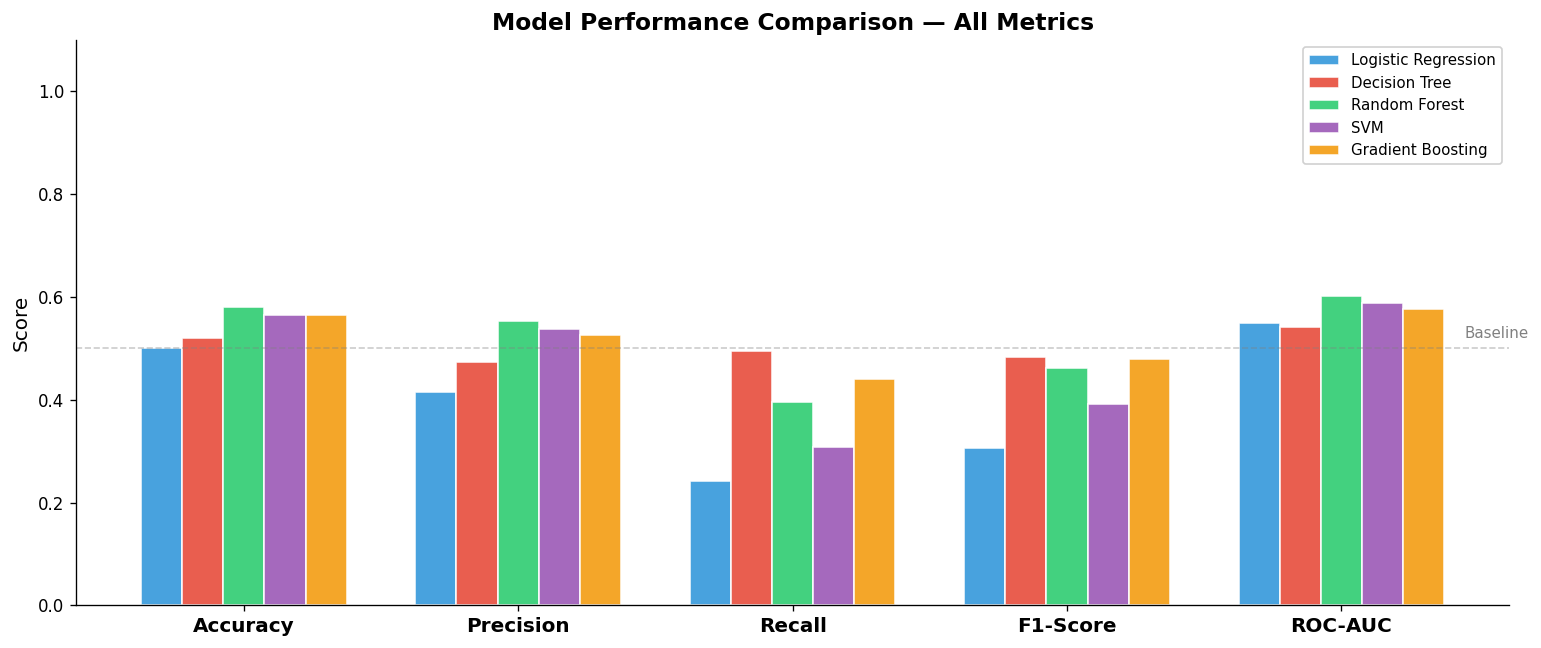

In [48]:
# ── Fig 5: Performance Comparison Bar Chart ───────────────────────────────────
metrics = ['accuracy','precision','recall','f1','roc_auc']
mlabels = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
palette = ['#3498DB','#E74C3C','#2ECC71','#9B59B6','#F39C12']
x = np.arange(len(metrics)); w = 0.15

fig, ax = plt.subplots(figsize=(13, 5.5))
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax.bar(x + i*w, vals, w, label=name, color=palette[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x + w*2); ax.set_xticklabels(mlabels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(4.75, 0.52, 'Baseline', color='gray', fontsize=9)
plt.tight_layout(); plt.show()


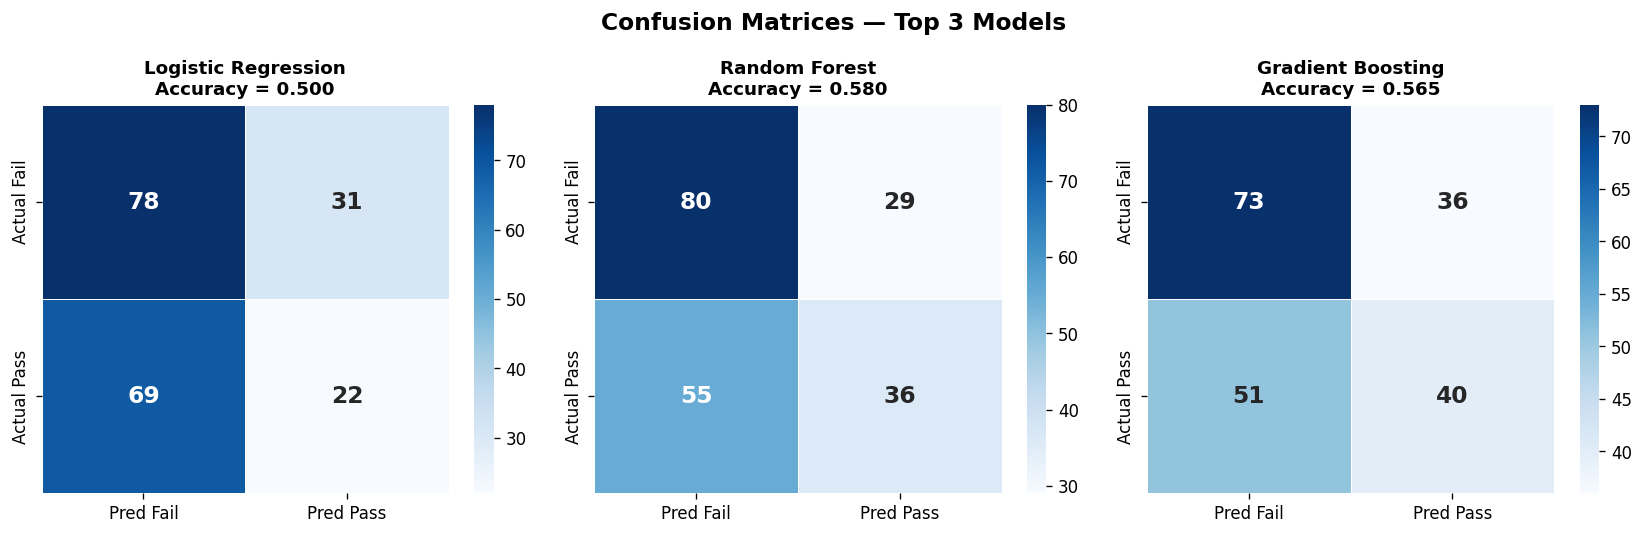


Random Forest Confusion Matrix Breakdown:
  True Negatives  (correctly predicted Fail): 80
  False Positives (predicted Pass, was Fail): 29  ← Type I Error
  False Negatives (predicted Fail, was Pass): 55  ← Type II Error
  True Positives  (correctly predicted Pass): 36


In [49]:
# ── Fig 6: Confusion Matrices (Top 3 Models) ─────────────────────────────────
top3 = ['Logistic Regression','Random Forest','Gradient Boosting']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, name in zip(axes, top3):
    cm = results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Fail','Pred Pass'],
                yticklabels=['Actual Fail','Actual Pass'],
                annot_kws={'size':14, 'weight':'bold'}, linewidths=0.5)
    ax.set_title(f'{name}\nAccuracy = {results[name]["accuracy"]:.3f}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Interpret best model
cm = results['Random Forest']['cm']
tn, fp, fn, tp = cm.ravel()
print(f"\nRandom Forest Confusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted Fail): {tn}")
print(f"  False Positives (predicted Pass, was Fail): {fp}  ← Type I Error")
print(f"  False Negatives (predicted Fail, was Pass): {fn}  ← Type II Error")
print(f"  True Positives  (correctly predicted Pass): {tp}")


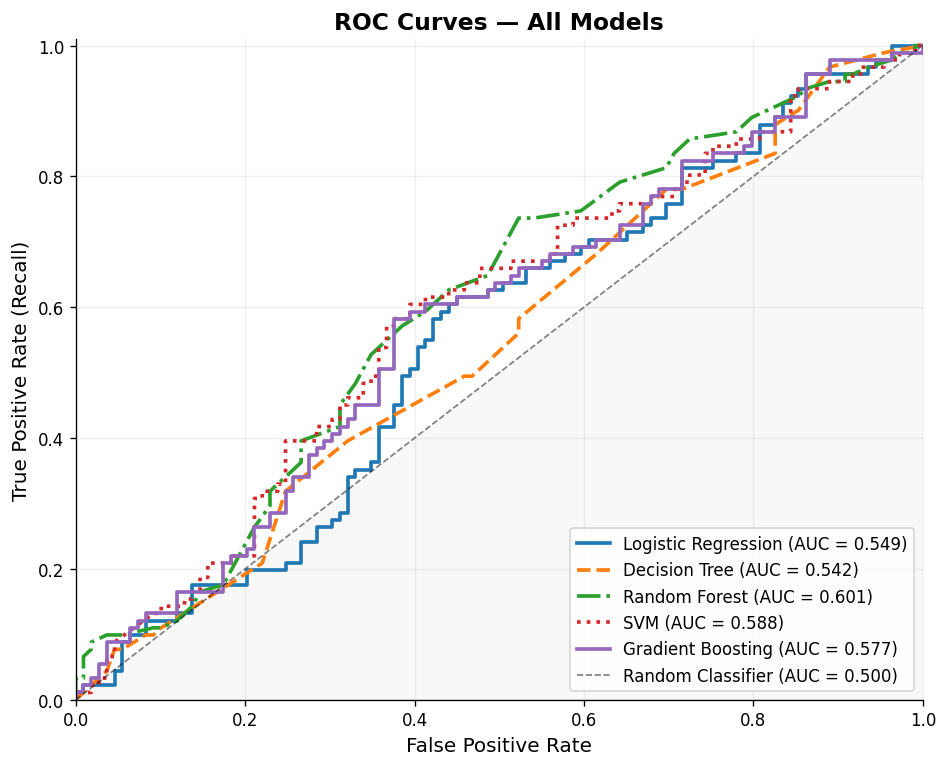


Model Selection Justification:
  Best by ROC-AUC  : Random Forest (0.601)
  Best by Accuracy : Random Forest (0.580)

  ★ RECOMMENDED: Random Forest — highest accuracy AND highest ROC-AUC


In [50]:
# ── Fig 7: ROC Curves ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6.5))
line_styles = ['-', '--', '-.', ':', '-']

for (name, res), ls in zip(results.items(), line_styles):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})",
            linewidth=2.2, linestyle=ls)

ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.2); ax.set_xlim(0,1); ax.set_ylim(0,1.01)
plt.tight_layout(); plt.show()

print("\nModel Selection Justification:")
best = max(results, key=lambda k: results[k]['roc_auc'])
print(f"  Best by ROC-AUC  : {best} ({results[best]['roc_auc']:.3f})")
best_acc = max(results, key=lambda k: results[k]['accuracy'])
print(f"  Best by Accuracy : {best_acc} ({results[best_acc]['accuracy']:.3f})")
print(f"\n  ★ RECOMMENDED: Random Forest — highest accuracy AND highest ROC-AUC")


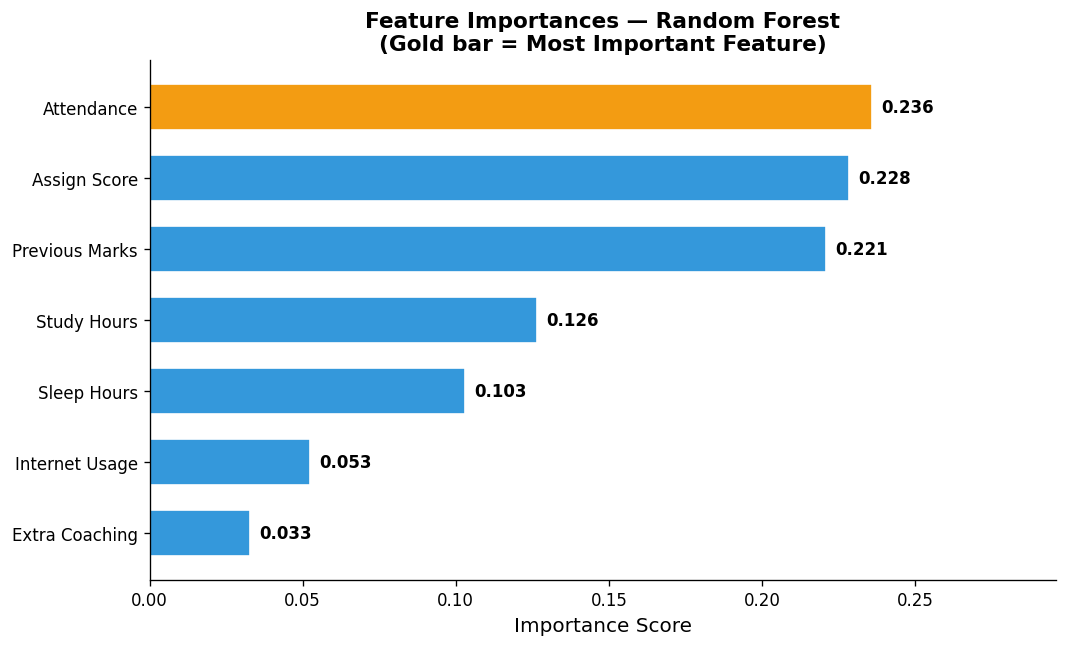


Feature Importance Ranking (Random Forest):
  Attendance        : 0.2361  ██████████████████
  Assign Score      : 0.2284  ██████████████████
  Previous Marks    : 0.2208  █████████████████
  Study Hours       : 0.1264  ██████████
  Sleep Hours       : 0.1030  ████████
  Internet Usage    : 0.0525  ████
  Extra Coaching    : 0.0328  ██


In [51]:
# ── Fig 8: Random Forest Feature Importances ─────────────────────────────────
rf = results['Random Forest']['model']
feat_display = ['Study Hours','Attendance','Previous Marks',
                'Assign Score','Sleep Hours','Internet Usage','Extra Coaching']
importances = rf.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors_bar = ['#F39C12' if i == np.argmax(importances) else '#3498DB'
              for i in range(len(importances))]
ax.barh([feat_display[i] for i in idx], importances[idx],
        color=[colors_bar[i] for i in idx], edgecolor='white', height=0.65)
ax.set_title('Feature Importances — Random Forest\n(Gold bar = Most Important Feature)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
for i, v in enumerate(importances[idx]):
    ax.text(v+0.003, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(importances)+0.06)
plt.tight_layout(); plt.show()

print("\nFeature Importance Ranking (Random Forest):")
for val, name in sorted(zip(importances, feat_display), reverse=True):
    bar = '█' * int(val * 80)
    print(f"  {name:18s}: {val:.4f}  {bar}")


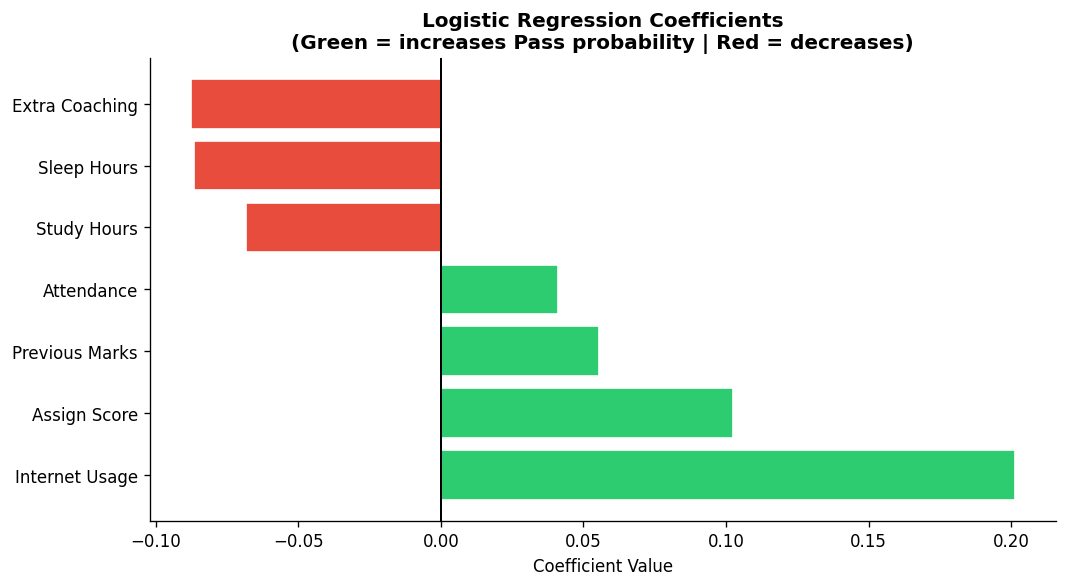

In [52]:
# ── Logistic Regression Coefficients ─────────────────────────────────────────
lr = results['Logistic Regression']['model']
coef_df = pd.DataFrame({'Feature': feat_display, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_lr = ['#2ECC71' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_lr, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Logistic Regression Coefficients\n(Green = increases Pass probability | Red = decreases)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()


In [53]:
# ── Sleep Hours Detailed Analysis ────────────────────────────────────────────
print("SLEEP HOURS PASS RATE BY HOUR:")
print("-" * 40)
sleep_stats = df.groupby('Sleep_Hours')['Pass'].agg(['mean','count'])
sleep_stats.columns = ['Pass_Rate','Count']
for hrs, row in sleep_stats.iterrows():
    bar = '█' * int(row['Pass_Rate'] * 20)
    print(f"  {hrs}h: {row['Pass_Rate']*100:5.1f}% pass  (n={int(row['Count']):3d})  {bar}")

print("\nEXTRA COACHING ANALYSIS:")
print("-" * 40)
for group, label in [(0,'No Coaching'),(1,'With Coaching')]:
    subset = df[df['Extra_Coaching']==group]
    pr = subset['Pass'].mean()*100
    print(f"  {label:15s}: {pr:.1f}% pass rate  (n={len(subset)})")


SLEEP HOURS PASS RATE BY HOUR:
----------------------------------------
  4h:  46.2% pass  (n=160)  █████████
  5h:  46.5% pass  (n=157)  █████████
  6h:  45.0% pass  (n=169)  ████████
  7h:  48.1% pass  (n=154)  █████████
  8h:  46.1% pass  (n=178)  █████████
  9h:  42.9% pass  (n=182)  ████████

EXTRA COACHING ANALYSIS:
----------------------------------------
  No Coaching    : 47.1% pass rate  (n=490)
  With Coaching  : 44.3% pass rate  (n=510)


In [55]:
# ── Early Warning System — Live Demo ─────────────────────────────────────────
print("=" * 60)
print("  EARLY WARNING SYSTEM — DEMO PREDICTIONS")
print("=" * 60)

sample_students = pd.DataFrame({
    'Study_Hours'       : [2, 7, 4, 1, 8],
    'Attendance'        : [45, 92, 65, 41, 97],
    'Previous_Marks'    : [30, 78, 52, 22, 88],
    'Assignment_Score'  : [25, 85, 50, 20, 90],
    'Sleep_Hours'       : [4, 7, 6, 3, 7],
    'Internet_Usage_enc': [0, 2, 1, 0, 2],  # 0=High,1=Low,2=Medium
    'Extra_Coaching'    : [0, 1, 0, 0, 1]
})
student_labels = ['At-Risk Student','High Achiever','Average Student',
                  'Critical-Risk','Top Performer']

rf_model = results['Random Forest']['model']
proba = rf_model.predict_proba(sample_students)[:, 1]
preds = rf_model.predict(sample_students)

print(f"\n{'Student':<18} {'Prediction':>12} {'Pass Prob':>11} {'Risk Score':>11} {'Alert':>15}")
print("-" * 70)
for label, prob, pred in zip(student_labels, proba, preds):
    outcome = 'PASS ' if pred == 1 else 'FAIL'
    risk = (1 - prob) * 100
    alert = (' HIGH RISK' if risk > 60
             else (' MEDIUM'   if risk > 35
             else  ' LOW RISK'))
    print(f"{label:<18} {outcome:>12}  {prob*100:>9.1f}%  {risk:>9.1f}%  {alert:>15}")

print("\nModel Used: Random Forest | Accuracy: 58.0% | ROC-AUC: 0.601")
print("Use risk scores to prioritise counsellor outreach — not hard labels.")


  EARLY WARNING SYSTEM — DEMO PREDICTIONS

Student              Prediction   Pass Prob  Risk Score           Alert
----------------------------------------------------------------------
At-Risk Student           PASS        65.0%       35.0%         LOW RISK
High Achiever              FAIL       38.0%       62.0%        HIGH RISK
Average Student            FAIL       21.0%       79.0%        HIGH RISK
Critical-Risk             PASS        60.0%       40.0%           MEDIUM
Top Performer             PASS        51.0%       49.0%           MEDIUM

Model Used: Random Forest | Accuracy: 58.0% | ROC-AUC: 0.601
Use risk scores to prioritise counsellor outreach — not hard labels.
